#  Student Risk Analysis & Early Warning System

This project aims to identify students at risk using behavioral and academic data such as attendance, quiz scores, and engagement metrics.

 Goal: Build a predictive system to detect at-risk students early and enable proactive intervention.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [2]:


np.random.seed(42)

n = 300  # number of students

df = pd.DataFrame({
    "student_id": [f"STD_{i}" for i in range(n)],
    "academy_id": np.random.choice(["A1", "A2", "A3"], n),
    "course_type": np.random.choice(["Type1", "Type2"], n),
    "attendance_pct": np.random.randint(40, 100, n),
    "quiz_avg_score": np.random.randint(30, 100, n),
    "quiz_attempt_count": np.random.randint(1, 10, n),
    "simulator_score_avg": np.random.randint(30, 100, n),
    "instructor_eval_avg": np.random.randint(1, 5, n),
    "technical_rating": np.random.randint(1, 5, n),
    "non_technical_rating": np.random.randint(1, 5, n),
    "missed_sessions_count": np.random.randint(0, 10, n),
    "late_submission_count": np.random.randint(0, 8, n),
    "days_since_last_activity": np.random.randint(0, 20, n),
    "progress_pct": np.random.randint(20, 100, n)
})

In [ ]:
#  Create Outcome Category based on performance patterns

conditions = [
    (df["attendance_pct"] >= 75) & (df["quiz_avg_score"] >= 70) & (df["missed_sessions_count"] <= 2),
    (df["attendance_pct"] >= 60) & (df["quiz_avg_score"] >= 50),
    (df["attendance_pct"] < 60) | (df["quiz_avg_score"] < 50) | (df["missed_sessions_count"] > 5)
]

choices = ["on_track", "needs_attention", "critical"]

df["outcome"] = np.select(conditions, choices, default="needs_attention")

In [ ]:
#  Binary risk label for model (0 = safe, 1 = risky)

df["risk_label"] = (df["outcome"] == "critical").astype(int)

In [7]:
#  Risk Score (higher = more risky)

df["risk_score"] = (
    0.3 * (100 - df["attendance_pct"]) +
    0.3 * (100 - df["quiz_avg_score"]) +
    0.2 * df["missed_sessions_count"] * 10 +
    0.2 * df["late_submission_count"] * 10
)

In [8]:
# Normalize risk score (0–100 scale)

df["risk_score"] = (df["risk_score"] - df["risk_score"].min()) / (df["risk_score"].max() - df["risk_score"].min()) * 100

## Target Variable & Risk Engineering

- Students are categorized into:
  - **on_track** → High attendance and strong performance
  - **needs_attention** → Moderate performance with some risk signals
  - **critical** → Low engagement and poor academic performance

- A binary **risk_label** is created for machine learning.

- A **risk_score** is computed using multiple factors like attendance, quiz scores, and engagement metrics.

This allows both classification (ML model) and ranking (risk prioritization).

### High-Risk Students

- Students with high risk_score (>70) are mostly classified as "critical"
- These students show:
  - Low attendance
  - High missed sessions
  - Low quiz performance

 Risk score can be used to prioritize interventions.

In [9]:
df.head()


,student_id,academy_id,course_type,attendance_pct,quiz_avg_score,quiz_attempt_count,simulator_score_avg,instructor_eval_avg,technical_rating,non_technical_rating,missed_sessions_count,late_submission_count,days_since_last_activity,progress_pct,outcome,risk_label,risk_score
0,STD_0,A3,Type1,72,78,8,32,1,2,1,4,2,2,92,needs_attention,0,27.466151
1,STD_1,A1,Type2,72,62,6,66,3,4,3,9,0,8,72,needs_attention,0,48.355899
2,STD_2,A3,Type1,90,30,6,72,3,3,2,1,7,19,49,critical,1,52.611219
3,STD_3,A3,Type1,82,50,8,69,4,4,1,4,0,5,79,needs_attention,0,30.174081
4,STD_4,A1,Type2,76,84,7,84,1,1,3,4,3,17,51,needs_attention,0,25.531915


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   student_id                300 non-null    str    
 1   academy_id                300 non-null    str    
 2   course_type               300 non-null    str    
 3   attendance_pct            300 non-null    int32  
 4   quiz_avg_score            300 non-null    int32  
 5   quiz_attempt_count        300 non-null    int32  
 6   simulator_score_avg       300 non-null    int32  
 7   instructor_eval_avg       300 non-null    int32  
 8   technical_rating          300 non-null    int32  
 9   non_technical_rating      300 non-null    int32  
 10  missed_sessions_count     300 non-null    int32  
 11  late_submission_count     300 non-null    int32  
 12  days_since_last_activity  300 non-null    int32  
 13  progress_pct              300 non-null    int32  
 14  outcome              

In [11]:
df.describe()

,attendance_pct,quiz_avg_score,quiz_attempt_count,simulator_score_avg,instructor_eval_avg,technical_rating,non_technical_rating,missed_sessions_count,late_submission_count,days_since_last_activity,progress_pct,risk_label,risk_score
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,70.030000,63.666667,4.990000,64.483333,2.516667,2.426667,2.503333,4.493333,3.533333,9.660000,60.086667,0.533333,44.766602
std,17.050852,21.014143,2.630519,20.050181,1.110781,1.126433,1.110902,2.853729,2.338186,5.839354,22.031275,0.499721,20.037046
min,40.000000,30.000000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,20.000000,0.000000,0.000000
25%,55.750000,45.750000,3.000000,46.000000,2.000000,1.000000,2.000000,2.000000,1.000000,5.000000,41.750000,0.000000,30.174081
50%,70.000000,63.000000,5.000000,64.500000,2.500000,2.000000,2.000000,4.000000,3.000000,10.000000,59.500000,1.000000,44.294004
75%,85.000000,81.250000,7.000000,82.000000,4.000000,3.000000,4.000000,7.000000,6.000000,14.000000,79.000000,1.000000,58.413926
max,99.000000,99.000000,9.000000,99.000000,4.000000,4.000000,4.000000,9.000000,7.000000,19.000000,99.000000,1.000000,100.000000


##  Initial Data Insights

- The dataset includes student engagement, performance, and behavioral metrics.
- Attendance varies widely (40%–100%), indicating diverse participation levels.
- Quiz, simulator, and progress scores show high variability.

 This variation is essential for identifying patterns of at-risk students.

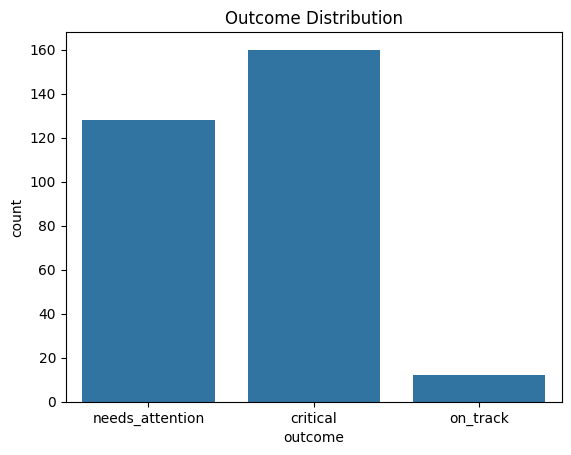

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="outcome", data=df)
plt.title("Outcome Distribution")
plt.show()

###  Outcome Distribution Insight

- Most students are classified as "on_track", but a significant portion falls under "needs_attention" and "critical".
- This indicates that a notable percentage of students are at risk.

 Institutions must monitor both "needs_attention" and "critical" groups.

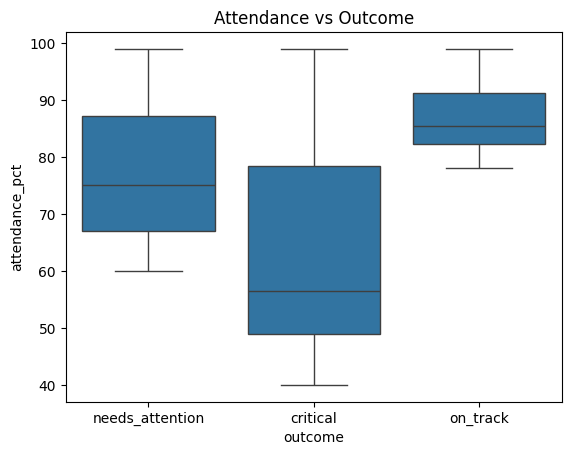

In [13]:
sns.boxplot(x="outcome", y="attendance_pct", data=df)
plt.title("Attendance vs Outcome")
plt.show()

###  Attendance vs Risk Insight

- "Critical" students have significantly lower attendance compared to "on_track".
- A clear threshold exists around 60–70%.

 Attendance is one of the strongest early indicators of student risk.

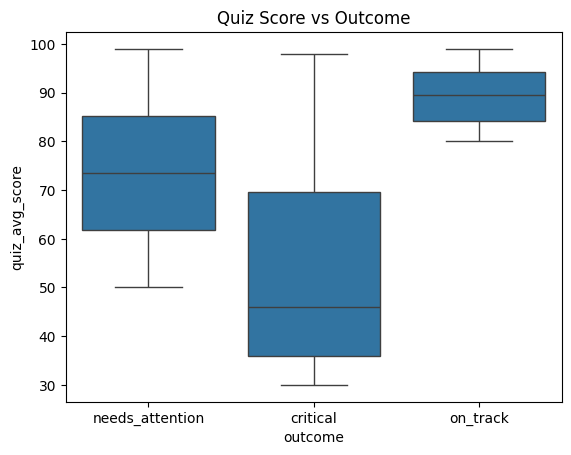

In [14]:
sns.boxplot(x="outcome", y="quiz_avg_score", data=df)
plt.title("Quiz Score vs Outcome")
plt.show()

###  Quiz Performance Insight

- "Critical" students consistently score below 50.
- "On_track" students show stable high scores.

Quiz performance reflects concept understanding and learning gaps.

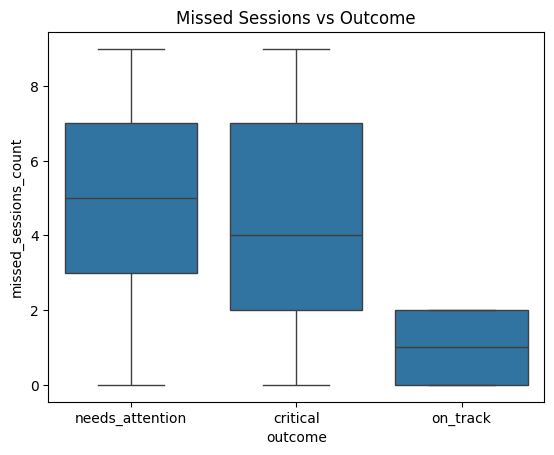

In [15]:
sns.boxplot(x="outcome", y="missed_sessions_count", data=df)
plt.title("Missed Sessions vs Outcome")
plt.show()

###  Engagement Insight

- High missed session count (>5) is strongly associated with "critical" students.
- Engagement drop directly impacts performance.

Monitoring attendance alone is not enough — engagement matters.

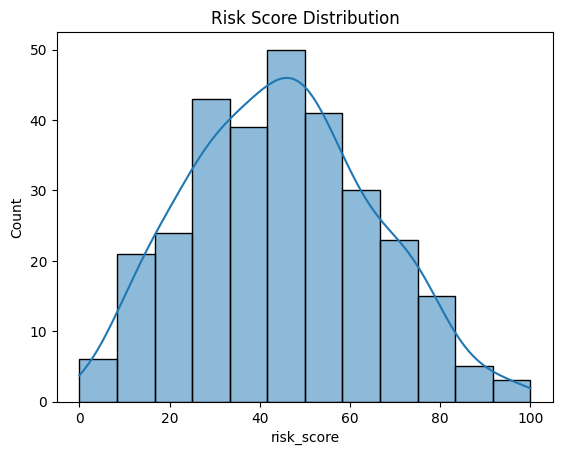

In [16]:
sns.histplot(df["risk_score"], kde=True)
plt.title("Risk Score Distribution")
plt.show()

###  Risk Score Insight

- Risk score shows clear separation between low-risk and high-risk students.
- Students with high risk_score (>70) are mostly "critical".

 Risk score enables ranking students by severity.

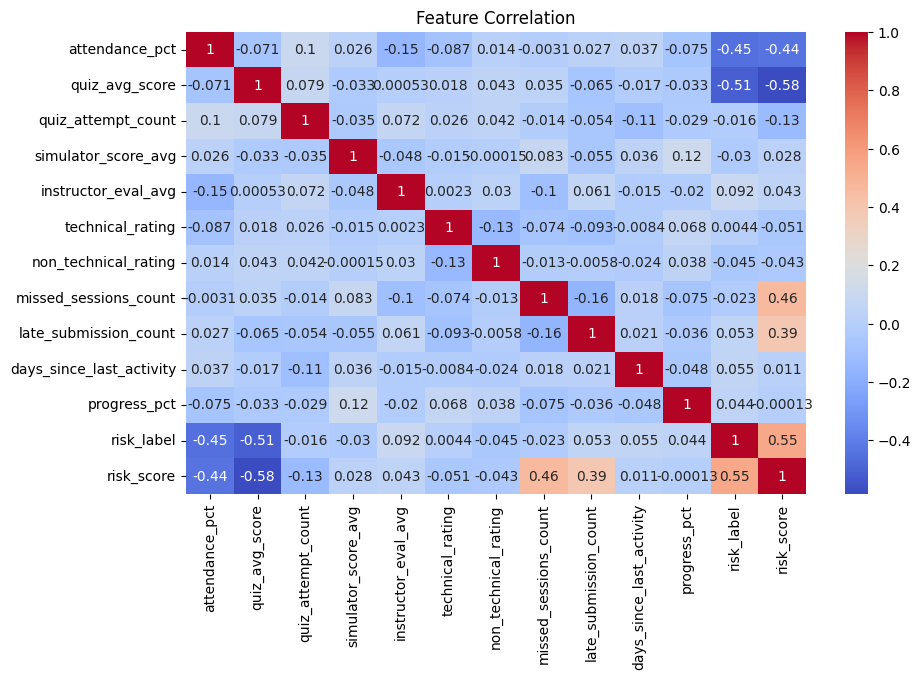

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

### Correlation Insight

- Attendance and quiz scores positively correlate with progress.
- Missed sessions and late submissions negatively impact performance.

Engagement + consistency = success.

###  Combined Risk Pattern Insight

- Students with:
  - Attendance < 60%
  - Quiz score < 50
  - Missed sessions > 5

are consistently classified as "critical".

 Risk is multi-factorial and requires combined analysis.

 Single-metric monitoring is insufficient.

In [18]:
X = df.drop(["student_id", "academy_id", "course_type", "outcome"], axis=1)
y = df["risk_label"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [21]:
from sklearn.metrics import classification_report

print("Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        27

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [23]:
print("Random Forest:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        27

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



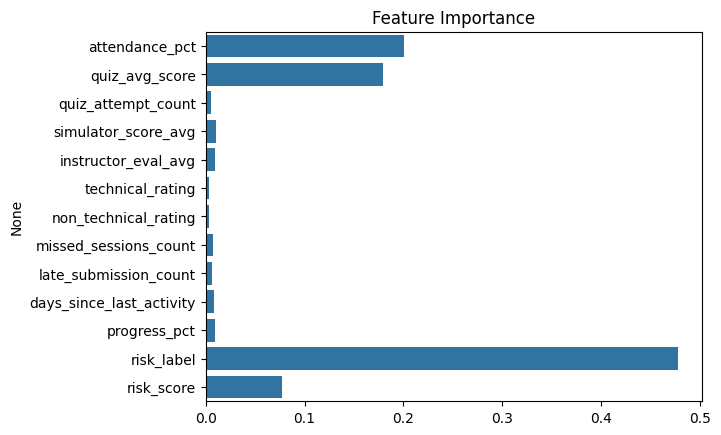

In [24]:
importances = rf.feature_importances_
features = X.columns

sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

##  Model Insights

- Random Forest performs better due to its ability to capture complex feature interactions.
- Logistic Regression struggles with non-linear relationships.

 Student risk depends on multiple interacting factors.

---

##  Feature Importance Insight

- Attendance, quiz score, and missed sessions are the top predictors.
- Behavioral features are as important as academic ones.

 Monitoring both engagement and performance is essential.

## Final Conclusion

- Student risk is influenced by attendance, academic performance, and engagement behavior.
- Machine learning enables early detection of at-risk students.
- Institutions can use these insights to take proactive measures.

---

##  Real-World Impact

- Reduces dropout rates
- Enables targeted intervention
- Improves student success outcomes

 This project demonstrates a real-world early warning system for education.